In [18]:
import json
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent

RESULTS_DIR = PROJECT_ROOT / "data" / "results"
EVALUATION_DIR = RESULTS_DIR / "evaluation"

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
print("Project root:", PROJECT_ROOT)

Project root: /Users/pallavi_chandanshive/projects/clinical-summarization-eval


In [9]:

# ---------------------------------------------------------
# Load final outputs from all four summarization workflows
# ---------------------------------------------------------
# These are the frozen final summaries that will be compared
# using the same evaluation methodology.

workflow_paths = {
    "direct": RESULTS_DIR / "direct" / "direct_summaries.json",
    "hierarchical": RESULTS_DIR / "hierarchical" / "hierarchical_summaries.json",
    "rag": RESULTS_DIR / "rag" / "final_rag_summaries.json",
    "rag_verification": RESULTS_DIR / "rag_verification" / "final_verified_summaries.json",
}

for workflow, path in workflow_paths.items():
    with open(path, "r") as f:
        data = json.load(f)

    print(f"\n--- {workflow} ---")
    print("Type:", type(data))
    print("Number of records:", len(data))

    if isinstance(data, list):
        print("First record keys:", data[0].keys())
    elif isinstance(data, dict):
        first_key = next(iter(data))
        print("First key:", first_key)
        print("First value type:", type(data[first_key]))

        if isinstance(data[first_key], dict):
            print("First value keys:", data[first_key].keys())


--- direct ---
Type: <class 'dict'>
Number of records: 50
First key: 028998ee-babc-4096-9b28-001bc2f9a84e
First value type: <class 'dict'>
First value keys: dict_keys(['person_id', 'source_note_count', 'summary', 'latency_seconds'])

--- hierarchical ---
Type: <class 'dict'>
Number of records: 50
First key: 028998ee-babc-4096-9b28-001bc2f9a84e
First value type: <class 'dict'>
First value keys: dict_keys(['person_id', 'source_note_count', 'intermediate_summary_count', 'final_summary'])

--- rag ---
Type: <class 'dict'>
Number of records: 50
First key: 028998ee-babc-4096-9b28-001bc2f9a84e
First value type: <class 'dict'>
First value keys: dict_keys(['person_id', 'source_chunk_count', 'retrieved_chunk_count', 'context_characters', 'context_words', 'summary', 'latency_seconds'])

--- rag_verification ---
Type: <class 'dict'>
Number of records: 50
First key: 028998ee-babc-4096-9b28-001bc2f9a84e
First value type: <class 'dict'>
First value keys: dict_keys(['person_id', 'revision_needed', 'i

In [13]:

# ---------------------------------------------------------
# Load and standardize final summaries from all workflows
# ---------------------------------------------------------
# Each workflow stores its final generated summary under a
# slightly different field name. Here we convert all four
# outputs into the same structure:
#
#     person_id | workflow | summary
#
# This standardized table will be reused throughout the
# final evaluation.

summary_fields = {
    "direct": "summary",
    "hierarchical": "final_summary",
    "rag": "summary",
    "rag_verification": "final_summary",
}

evaluation_records = []
workflow_patient_ids = {}


for workflow, path in workflow_paths.items():

    with open(path, "r") as f:
        data = json.load(f)

    # Save patient IDs so we can verify that every workflow
    # was run on exactly the same study cohort.
    workflow_patient_ids[workflow] = set(data.keys())

    summary_field = summary_fields[workflow]

    for person_id, record in data.items():

        evaluation_records.append({
            "person_id": person_id,
            "workflow": workflow,
            "summary": record[summary_field]
        })


# Create one evaluation dataframe containing all summaries.
evaluation_df = pd.DataFrame(evaluation_records)


# ---------------------------------------------------------
# Verify cohort consistency
# ---------------------------------------------------------
# Final comparisons are only valid if all four workflows
# contain exactly the same patients.

reference_ids = workflow_patient_ids["direct"]

for workflow, patient_ids in workflow_patient_ids.items():

    print(
        f"{workflow:20s}: "
        f"{len(patient_ids)} patients | "
        f"matches Direct = {patient_ids == reference_ids}"
    )


print("\nTotal evaluation summaries:", len(evaluation_df))

print("\nSummaries per workflow:")
print(
    evaluation_df["workflow"]
    .value_counts()
    .sort_index()
)

direct              : 50 patients | matches Direct = True
hierarchical        : 50 patients | matches Direct = True
rag                 : 50 patients | matches Direct = True
rag_verification    : 50 patients | matches Direct = True

Total evaluation summaries: 200

Summaries per workflow:
workflow
direct              50
hierarchical        50
rag                 50
rag_verification    50
Name: count, dtype: int64


In [14]:
# ---------------------------------------------------------
# Inspect available processed data files
# ---------------------------------------------------------
# TF-IDF will compare each generated summary against the
# patient's complete cleaned and deduplicated clinical record.
#
# Before constructing those source documents, inspect the
# processed-data directory so we use the exact dataset that
# was used by the summarization workflows.

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Available processed files:\n")

for path in sorted(PROCESSED_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(PROCESSED_DIR))

Available processed files:

hierarchical_note_summaries.json
rag_atomic_claims.json
rag_long_summaries/rag_atomic_claims_gpt56luna.json
rag_long_summaries/rag_claim_faithfulness_gpt56luna.json
rag_long_summaries/rag_config_summaries_gpt56luna_top20.json
rag_long_summaries/rag_coverage_gpt56luna.json
rag_long_summaries/rag_faithfulness_summary_gpt56luna.csv
rag_long_summaries/rag_final_priority_ranking.csv
rag_long_summaries/rag_temporal_consistency_gpt56luna.csv
rag_long_summaries/rag_tfidf_similarity_gpt56luna_top20.csv
rag_long_summaries/section_bge_generated_summary.txt
rag_long_summaries/section_chunks.csv
rag_short_summaries/faithfulness_source_gemini_embeddings.npy
rag_short_summaries/rag_atomic_claims_gpt56luna.json
rag_short_summaries/rag_claim_faithfulness_gpt56luna.json
rag_short_summaries/rag_configuration_summaries.json
rag_short_summaries/rag_faithfulness_summary_gpt56luna.csv
rag_short_summaries/rag_final_priority_ranking.csv
rag_short_summaries/rag_reference_fact_coverag

In [15]:
# ---------------------------------------------------------
# Locate the original clinical notes dataset
# ---------------------------------------------------------
# The processed directory contains derived workflow artifacts,
# not the final deduplicated source-note table.
#
# Locate the original clinical_notes.csv so we can recreate
# the exact frozen preprocessing used by all workflows.

for path in PROJECT_ROOT.rglob("clinical_notes.csv"):
    print(path.relative_to(PROJECT_ROOT))

data/raw/clinical_notes.csv


In [16]:
# ---------------------------------------------------------
# Reconstruct the frozen deduplicated clinical-note corpus
# ---------------------------------------------------------
# TF-IDF must use the same source records that were used by
# the four summarization workflows.
#
# The original dataset contains some invalid "#NAME?" notes
# and duplicate note text. We therefore reproduce the exact
# preprocessing rules that were frozen earlier in the study.

CLINICAL_NOTES_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "clinical_notes.csv"
)

notes = pd.read_csv(CLINICAL_NOTES_PATH)


# Remove invalid notes whose entire cleaned text is "#NAME?"
notes_clean = notes[
    notes["clean_note_text"]
    .astype(str)
    .str.strip() != "#NAME?"
].copy()


# Sort notes chronologically within each patient and remove
# duplicate note text. If the same note occurs multiple times,
# retain its earliest occurrence.
notes_dedup = (
    notes_clean
    .sort_values([
        "person_id",
        "creation_timestamp"
    ])
    .drop_duplicates(
        subset=[
            "person_id",
            "clean_note_text"
        ],
        keep="first"
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Validate preprocessing
# ---------------------------------------------------------
# These values should reproduce our previously frozen cohort:
#   Original notes:        1,602
#   After #NAME? removal:  1,595
#   After deduplication:    1,103
#   Patients:                  50

print("Original notes:", len(notes))
print("After #NAME? removal:", len(notes_clean))
print("After deduplication:", len(notes_dedup))
print(
    "Patients:",
    notes_dedup["person_id"].nunique()
)

Original notes: 1602
After #NAME? removal: 1595
After deduplication: 1103
Patients: 50


In [17]:
# ---------------------------------------------------------
# Build one longitudinal source document per patient
# ---------------------------------------------------------
# Each patient's deduplicated clinical notes are already
# ordered chronologically by creation_timestamp.
#
# We concatenate those notes into one complete source
# document per patient. This gives TF-IDF a consistent
# source record against which each workflow summary can
# be compared.

patient_source_documents = (
    notes_dedup
    .groupby("person_id", sort=False)["clean_note_text"]
    .apply(
        lambda texts: "\n\n".join(
            texts.astype(str)
        )
    )
    .to_dict()
)


# ---------------------------------------------------------
# Validate source/evaluation cohort alignment
# ---------------------------------------------------------
# Every patient being evaluated must have exactly one
# complete source document.

source_patient_ids = set(
    patient_source_documents.keys()
)

evaluation_patient_ids = set(
    evaluation_df["person_id"].unique()
)

print(
    "Source documents:",
    len(patient_source_documents)
)

print(
    "Evaluation patients:",
    len(evaluation_patient_ids)
)

print(
    "Patient IDs match:",
    source_patient_ids == evaluation_patient_ids
)

print(
    "Missing source records:",
    evaluation_patient_ids - source_patient_ids
)

print(
    "Extra source records:",
    source_patient_ids - evaluation_patient_ids
)

Source documents: 50
Evaluation patients: 50
Patient IDs match: True
Missing source records: set()
Extra source records: set()


In [29]:
# ---------------------------------------------------------
# Patient-specific source-derived TF-IDF evaluation
# ---------------------------------------------------------
# For each patient:
# 1. Fit TF-IDF only on that patient's original notes.
# 2. Build the complete longitudinal source record.
# 3. Transform the source and all four workflow summaries.
# 4. Compute cosine similarity between the source and each
#    generated summary.
#
# Generated summaries never influence the TF-IDF vocabulary
# or IDF weights.


# ---------------------------------------------------------
# Pre-group data once
# ---------------------------------------------------------
# Avoid repeatedly filtering the full dataframes inside
# the patient loop.

notes_by_patient = {
    person_id: group.sort_values("creation_timestamp")[
        "clean_note_text"
    ].astype(str).tolist()
    for person_id, group in notes_dedup.groupby("person_id")
}

summaries_by_patient = {
    person_id: group
    for person_id, group in evaluation_df.groupby("person_id")
}

In [30]:
# ---------------------------------------------------------
# Calculate patient-level TF-IDF similarities
# ---------------------------------------------------------

tfidf_results = []

for person_id in sorted(evaluation_patient_ids):

    patient_notes = notes_by_patient[person_id]
    patient_summaries = summaries_by_patient[person_id]

    # Fit vocabulary and IDF weights using source notes only.
    vectorizer = TfidfVectorizer()
    vectorizer.fit(patient_notes)

    # Complete longitudinal source record.
    source_text = "\n\n".join(patient_notes)

    # Transform the source and all workflow summaries together.
    texts = [
        source_text,
        *patient_summaries["summary"].astype(str).tolist()
    ]

    vectors = vectorizer.transform(texts)

    source_vector = vectors[0]
    summary_vectors = vectors[1:]

    # Compare all four summaries with the source at once.
    similarities = cosine_similarity(
        source_vector,
        summary_vectors
    ).flatten()

    for workflow, similarity in zip(
        patient_summaries["workflow"],
        similarities
    ):
        tfidf_results.append({
            "person_id": person_id,
            "workflow": workflow,
            "tfidf_cosine": float(similarity),
            "source_note_count": len(patient_notes)
        })

In [31]:
# ---------------------------------------------------------
# Store results
# ---------------------------------------------------------

tfidf_df = pd.DataFrame(tfidf_results)


In [32]:
# ---------------------------------------------------------
# Validate  Results
# ---------------------------------------------------------

print("Total TF-IDF scores:", len(tfidf_df))

print("\nScores per workflow:")
print(
    tfidf_df["workflow"]
    .value_counts()
    .sort_index()
)

print(
    "\nScore range:",
    tfidf_df["tfidf_cosine"].min(),
    "to",
    tfidf_df["tfidf_cosine"].max()
)

Total TF-IDF scores: 200

Scores per workflow:
workflow
direct              50
hierarchical        50
rag                 50
rag_verification    50
Name: count, dtype: int64

Score range: 0.385129849327686 to 0.6703846935171303


In [33]:
# ---------------------------------------------------------
# Sanity-check patient-level TF-IDF results
# ---------------------------------------------------------
# Each patient should have exactly one TF-IDF score for each
# of the four workflows.
#
# Pivoting lets us inspect all four workflow scores for the
# same patient side by side.

tfidf_pivot = tfidf_df.pivot(
    index="person_id",
    columns="workflow",
    values="tfidf_cosine"
)


# Expected shape:
# 50 patients × 4 workflows
print("TF-IDF comparison shape:", tfidf_pivot.shape)


# There should be no missing scores for any workflow.
print("\nMissing scores:")
print(tfidf_pivot.isna().sum())


# Inspect the first 10 patients.
tfidf_pivot.head(10)

TF-IDF comparison shape: (50, 4)

Missing scores:
workflow
direct              0
hierarchical        0
rag                 0
rag_verification    0
dtype: int64


workflow,direct,hierarchical,rag,rag_verification
person_id,,,,
028998ee-babc-4096-9b28-001bc2f9a84e,0.506613,0.492610,0.534287,0.534287
04df53ea-55c1-48d9-84a1-1f15c133b29b,0.548379,0.552930,0.502373,0.502373
05192757-942f-460d-b4ff-004ec39cc5ee,0.545007,0.509839,0.551388,0.545427
0c04d9fb-d8d0-4ee0-8fc9-0c3f7f148bdf,0.597073,0.643408,0.570583,0.559996
0f438665-d430-4adb-8acc-c3beed9e4942,0.634622,0.627259,0.633261,0.633261
136c7916-4f9b-4e5c-bf01-77e9d2c681a2,0.502077,0.517759,0.485770,0.480475
137b8481-4f1d-4b7f-babd-20f7117023ad,0.541218,0.515947,0.493597,0.493597
1705dd0f-011a-492c-b006-b27e03f2f4ed,0.619638,0.620343,0.607212,0.607212
1dbe23dc-0d1e-431b-81eb-497282b46a14,0.565569,0.540515,0.559253,0.544755


In [34]:
# ---------------------------------------------------------
# Descriptive statistics by workflow
# ---------------------------------------------------------
# We now summarize the 50 patient-level TF-IDF scores for
# each workflow.
#
# Mean gives the average lexical similarity.
# Median shows the typical patient while being less affected
# by unusually high or low scores.
# Standard deviation (SD) shows how much scores vary across
# patients.
# Min and max show the observed range.

tfidf_summary = (
    tfidf_df
    .groupby("workflow")["tfidf_cosine"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

tfidf_summary.round(4)

,mean,median,std,min,max
workflow,,,,,
direct,0.5484,0.5372,0.0485,0.4737,0.6530
hierarchical,0.5368,0.5293,0.0487,0.4471,0.6704
rag,0.5234,0.5215,0.0551,0.3851,0.6487
rag_verification,0.5207,0.5200,0.0547,0.3851,0.6497


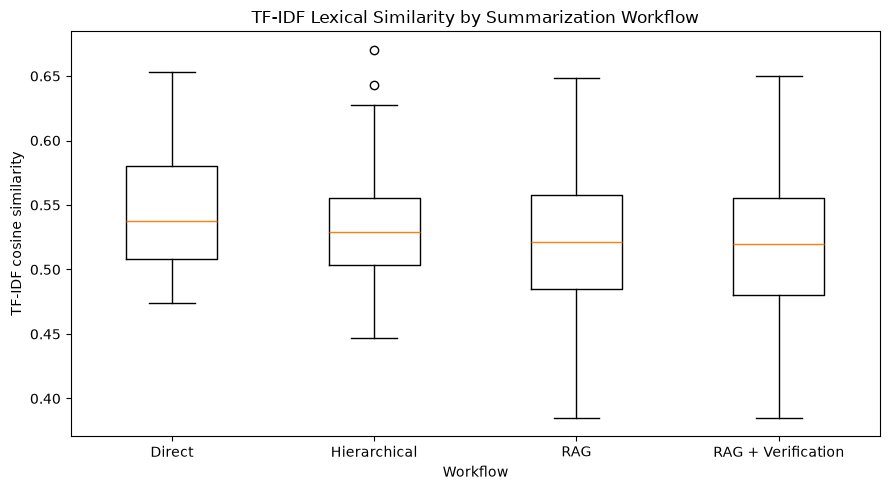

In [35]:
# ---------------------------------------------------------
# Visualize TF-IDF score distributions by workflow
# ---------------------------------------------------------
# A boxplot lets us compare the distribution of the 50
# patient-level scores across the four workflows.
#
# This helps us see:
# - the median score,
# - spread across patients,
# - possible outliers,
# - and how strongly the workflow distributions overlap.

import matplotlib.pyplot as plt

workflow_order = [
    "direct",
    "hierarchical",
    "rag",
    "rag_verification"
]

plot_data = [
    tfidf_df.loc[
        tfidf_df["workflow"] == workflow,
        "tfidf_cosine"
    ].values
    for workflow in workflow_order
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    plot_data,
    tick_labels=[
        "Direct",
        "Hierarchical",
        "RAG",
        "RAG + Verification"
    ]
)

plt.ylabel("TF-IDF cosine similarity")
plt.xlabel("Workflow")
plt.title("TF-IDF Lexical Similarity by Summarization Workflow")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Check normality of paired workflow differences
# ---------------------------------------------------------
# Because the same 50 patients are evaluated under every
# workflow, statistical comparisons are paired.
#
# For repeated-measures ANOVA, the relevant assumption is
# related to the distribution of within-patient differences,
# rather than simply checking each workflow independently.
#
# We calculate all six pairwise workflow differences and
# apply the Shapiro-Wilk normality test to each.

from itertools import combinations
from scipy.stats import shapiro

workflow_order = ["direct", "hierarchical", "rag", "rag_verification"]

normality_results = []

for workflow_a, workflow_b in combinations(workflow_order, 2):

    differences = tfidf_pivot[workflow_a] - tfidf_pivot[workflow_b]

    statistic, p_value = shapiro(differences)

    normality_results.append(
        {
            "comparison": f"{workflow_a} - {workflow_b}",
            "shapiro_statistic": statistic,
            "p_value": p_value,
        }
    )


normality_df = pd.DataFrame(normality_results)

normality_df.round(4)

,comparison,shapiro_statistic,p_value
0,direct - hierarchical,0.9757,0.3891
1,direct - rag,0.9791,0.5136
2,direct - rag_verification,0.9831,0.6872
3,hierarchical - rag,0.9880,0.8878
4,hierarchical - rag_verification,0.9897,0.9395
5,rag - rag_verification,0.8879,0.0002


In [37]:
# ---------------------------------------------------------
# Friedman test: overall workflow comparison
# ---------------------------------------------------------
# Tests whether TF-IDF scores differ systematically across
# the four workflows for the same 50 patients.

from scipy.stats import friedmanchisquare

friedman_stat, friedman_p = friedmanchisquare(
    tfidf_pivot["direct"],
    tfidf_pivot["hierarchical"],
    tfidf_pivot["rag"],
    tfidf_pivot["rag_verification"]
)

print("Friedman statistic:", round(friedman_stat, 4))
print("p-value:", round(friedman_p, 6))

Friedman statistic: 34.3636
p-value: 0.0


In [38]:
# ---------------------------------------------------------
# Save final TF-IDF evaluation results
# ---------------------------------------------------------
# We save:
# 1. Patient-level scores: 50 patients × 4 workflows = 200
# 2. Workflow-level descriptive statistics for reporting
#
# These files represent the frozen TF-IDF evaluation output.

TFIDF_RESULTS_PATH = (
    EVALUATION_DIR / "tfidf_patient_scores.csv"
)

TFIDF_SUMMARY_PATH = (
    EVALUATION_DIR / "tfidf_workflow_summary.csv"
)


# Save all patient-workflow TF-IDF scores.
tfidf_df.to_csv(
    TFIDF_RESULTS_PATH,
    index=False
)


# Save workflow-level descriptive statistics.
tfidf_summary.to_csv(
    TFIDF_SUMMARY_PATH
)


print("Saved patient-level results:")
print(TFIDF_RESULTS_PATH)

print("\nSaved workflow summary:")
print(TFIDF_SUMMARY_PATH)

Saved patient-level results:
/Users/pallavi_chandanshive/projects/clinical-summarization-eval/data/results/evaluation/tfidf_patient_scores.csv

Saved workflow summary:
/Users/pallavi_chandanshive/projects/clinical-summarization-eval/data/results/evaluation/tfidf_workflow_summary.csv
